# Notebook workflow — high-level overview
#
# Inputs:
# - `data/combined_dataset_*.tsv`: combined survey and administrative datasets (CBCR, BEA, CFC, etc.)
# - Supporting raw files in `data_raw/` and lookup tables in `data/` (e.g., `cit.dump`)
#
# Processing steps (this notebook):
# 1) Read and filter source datasets; unify identifiers (`iso`, `iso3`, `year`).
# 2) Compute ETR measures (cash and accrual), profit-per-employee, and other per-country statistics.
# 3) Identify candidate tax havens and key aggregates (domestic, foreign, havens).
# 4) Create summary tables and plots comparing CBCR, BEA, and Compustat measures.
# 5) Run misalignment calculations and regressions to estimate elasticities and shifts.
#
# Outputs:
# - Excel summaries under `results/` and `data/` (e.g., `data/stats_financials.xlsx`).
# - Figures saved to the `img/` paths referenced in plotting cells.
#
# Notes for readers:
# - Cells that follow are grouped by analysis stage (1. Read data, 2. Fix double counting, 3. Comparison of results).
# - Inline comments label purpose, inputs, and outputs. If you intend to re-run the notebook, ensure
#   the `results/` directory exists (first cells create it) and required raw data files are present.


In [1]:
# Create paths
!mkdir results
!mkdir results/figures


mkdir: results: File exists
mkdir: results/figures: File exists


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
#Process
import pandas as pd
import sys  
import pickle
from adjustText import adjust_text

#Library with tools to get country names
from data_processing import *

#Functions to do some plots
from f_helper import *

#PLot
import pylab as plt
import seaborn as sns


pd.set_option('chained_assignment',None)


In [22]:
# List of tax havens
dev_haven = ["NLD","CHE","SGP","IRL","HKG"]
island_states = "CYM, BMU, PRI, JEY, BHS, IMN, BRB, GIB, LUX, UK_Caribbean, BEA_Other_Europe, BEA_Other_Western, VGB, MUS, MLT".split(", ")

tax_havens = dev_haven + island_states
cs = ['USA', 'EGY', 'GAB', 'GHA', 'KEN', 'MUS', 'MAR', 'ZAF', 'TZA', 'UGA', 'ARG', 'BMU', 'BOL', 'BRA', 'CAN', 'CYM', 'CHL', 'COL', 'CRI', 'DOM', 'ECU', 'SLV', 'GTM', 'HND', 'JAM', 'MEX', 'PAN', 'PER', 'PRI', 'TTO', 'URY', 'VEN', 'VIR', 'AUS', 'BHR', 'BGD',
       'MMR', 'CHN', 'HKG', 'IND', 'IDN', 'ISR', 'JPN', 'KAZ', 'KOR', 'LBN', 'MYS', 'NZL', 'OMN', 'PAK', 'PHL', 'QAT', 'SAU', 'SGP', 'THA', 'ARE', 'VNM', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA',
       'LTU', 'LUX', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SRB', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'TUR', 'UKR', 'GBR', 'USA', 'CIV', 'EGY', 'GHA', 'KEN', 'MUS', 'MAR', 'NGA', 'SEN', 'ZAF', 'TZA', 'TUN', 'ZMB', 'ARG', 'BRB', 'BMU', 'BRA', 'CAN', 'CYM',
       'CHL', 'COL', 'CRI', 'DOM', 'ECU', 'SLV', 'GTM', 'HND', 'JAM', 'MEX', 'PAN', 'PRY', 'PER', 'PRI', 'TTO', 'URY', 'VEN', 'VIR', 'AUS', 'BGD', 'CHN', 'HKG', 'IND', 'IDN', 'ISR', 'JPN', 'KAZ', 'KOR', 'LBN', 'MAC', 'MYS', 'NZL', 'PAK', 'PHL', 'QAT', 'SAU',
       'SGP', 'LKA', 'TWN', 'THA', 'ARE', 'VNM', 'AUT', 'BEL', 'BIH', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SRB', 'SVK', 'SVN', 'ESP', 'SWE',
       'CHE', 'TUR', 'UKR', 'GBR', 'USA', 'CIV', 'EGY', 'GHA', 'KEN', 'MUS', 'MAR', 'SEN', 'ZAF', 'TZA', 'TUN', 'ZMB', 'ARG', 'BRB', 'BMU', 'BOL', 'BRA', 'CAN', 'CYM', 'CHL', 'COL', 'CRI', 'DOM', 'ECU', 'SLV', 'GTM', 'HND', 'JAM', 'MEX', 'NIC', 'PAN', 'PER',
       'PRI', 'URY', 'VEN', 'AUS', 'BGD', 'MMR', 'CHN', 'HKG', 'IND', 'IDN', 'ISR', 'JPN', 'KAZ', 'KOR', 'LBN', 'MAC', 'MYS', 'NZL', 'PAK', 'PHL', 'QAT', 'SAU', 'SGP', 'TWN', 'THA', 'VNM', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'FIN', 'FRA', 'DEU',
       'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'NLD', 'POL', 'PRT', 'ROU', 'RUS', 'SRB', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'TUR', 'UKR', 'GBR'] 


print([iso3_to_iso2(_) for _ in dev_haven])
print([iso3_to_iso2(_) for _ in island_states])

source_to_label = {"BEA_income": "BoP Income + foreign taxes",
                  "BEA_return": "BEA: Profit-type return",
                   "BEA_return_cg": "BEA: Profit-type return + capital gains",
                  "CFC": "CFC Form 5471: E&P - dividends",
                  "CBCR": "CBCR: Profits"}


# CITs, collected manually from various sources
iso3_to_cit = pickle.load(open("./data/cit.dump","rb"))


['NL', 'CH', 'SG', 'IE', 'HK']
UK_Caribbean not matched to any file
BEA_Other_Europe not matched to any file
BEA_Other_Western not matched to any file
['KY', 'BM', 'PR', 'JE', 'BS', 'IM', 'BB', 'GI', 'LU', 'UK_Caribbean', 'BEA_Other_Europe', 'BEA_Other_Western', 'VG', 'MU', 'MT']


# 1. Read data and basic stats


In [6]:
# CLEANED BEA AND CBCR DATA
include_stateless = False
fix_proportional = "_prop_change"
df = pd.read_csv(f"data/combined_dataset_stateless_{include_stateless}_all_False.tsv",sep="\t",index_col=None)
df["pi_emp"] = df["pi"]/df["emp"]  
df = df.loc[df["year"]<=2021]
df["iso3"] = df["iso"].replace({
                            "IRS_Other_America":"Other America",
                            "IRS_Other_Asia_Oceania":"Other America",
                            "IRS_Other_Africa":"Other Africa",
                            "IRS_Other_Europe":"Other Europe"
                            })

# CLEANED National accounts data (national_accounts_WrightZucman2018Appendix)
nat_acc = pd.read_excel("data_raw/national_accounts_WrightZucman2018Appendix.xlsx",sheet_name="T.A1",skiprows=7,index_col=0)
nat_acc = nat_acc[["Equals:            pre-tax USDIA equity income","Share of foreign pre-tax income in US corporations' pre-tax income (excl. S-corps)"]].dropna()
nat_acc.columns = ["Rest","share_fo"]

# CLEANED compustat
comp = pd.read_excel("data/compustat_all_etrs.xlsx")
comp["share_fo"] = comp["share_pi_fo_winsor_all"]#/comp["pi"]
comp = comp.loc[(comp["year"]<=2020)&(comp["year"]>1984)].set_index("year")

# DOMESTIC PROFITS (bea)
df_usa = pd.read_excel("data/GJZ2021Data.xlsx", skiprows=4, header=None, sheet_name="Data")[[0, 14, 15, 16]].dropna()
df_usa = df_usa.set_index(0)[[14,15,16]]
df_usa[[14,15]] *= 1E9
df_usa = df_usa.loc[:2019] 
#(GJZ to 2019; fill 2020–2021 from corrected BEA)
df_usa2 = [30.955152, 34.963433, 26.114557 ] # see regression for more explanation


/Users/garci061/miniforge3/envs/test3/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [7]:
# Three sources within df
bea_sf = df.loc[(df["year"]<2020) & df["iso"].isin(["Rest","USA"]) & (df["source"]=="BEA_return") & (df["type"] == "all_groups"),["iso","type","year","txc","txt","pi"]]
bea_sf = pd.pivot_table(bea_sf,values="pi",index="year",columns="iso")
bea_sf["share_fo"] = bea_sf["Rest"]/(bea_sf["Rest"]+bea_sf["USA"])

bea_sf_cg = df.loc[(df["year"]<2020) & df["iso"].isin(["Rest","USA"]) & (df["source"]=="BEA_return_cg") & (df["type"] == "all_groups"),["iso","type","year","txc","txt","pi"]]
bea_sf_cg = pd.pivot_table(bea_sf_cg,values="pi",index="year",columns="iso")
bea_sf_cg["share_fo"] = bea_sf_cg["Rest"]/(bea_sf_cg["Rest"]+bea_sf_cg["USA"])


cbcr_sf = df.loc[(df["year"]<2020) & df["iso"].isin(["Rest","USA"]) & (df["source"]=="CBCR") & (df["type"] == "all_groups"),["iso","type","year","txc","txt","pi"]]
cbcr_sf = pd.pivot_table(cbcr_sf,values="pi",index="year",columns="iso")
cbcr_sf["share_fo"] = cbcr_sf["Rest"]/(cbcr_sf["Rest"]+cbcr_sf["USA"])



## Figure 1a and A1: Share of foreign profits

Note on Figure 1b:
```
Graphics are produced using the latest version of the Orbis database, and one of its past version (third). The method is similar for each of the four firms.

To get the consolidated profits, we substract for each year the global financial profits and losses to the global profits and losses before tax. Those two information used to construct the "true global profits" bars were extracted for all ploted years (2013 to 2020) from the latest available version of Orbis (as of October 2021). 


The method used to get the sum of observal profits is different between all years until 2018, and between each of the two subsequent years. 

Until 2018, we use a historic version of Orbis (3). For each year from 2013 to 2018 we extract all listed Bureau Van Dijk identification numbers of the listed subsidiaries in a given year. We sum the profits and losses before tax of all subsidiaries of a given year
 made that year, and substract the summed financial profits and losses registered that year. 

For the bars of the sum observable profits in 2019, we do not have the list of exact subsidiaries listed that year neither in the third version of Orbis Historic nor in the latest version of Orbis. Therefore, we pool our identicication numbers of subsidiraies listed in Orbis historic for previous years and those listed as current subsidiaries of the firm in the latest version of Orbis. In the latest online version of Orbis we extract the profits and losses before tax as well as financial profits and losses registered in 2019 for all those subsidiaries and substract to the sum of former the sum of the latter. 

Finally, in 2020, we use the list of current subsidiaries identification numbers, available in the latest version of Orbis. We extract and sum their profits and losses before tax as well as their financial profits and losses and substract the latter from the former.
```

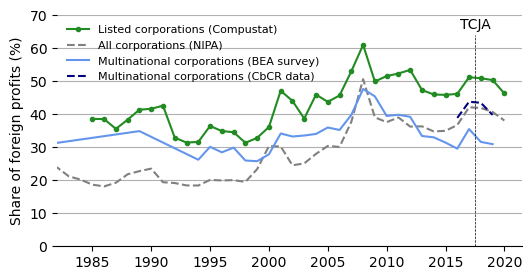

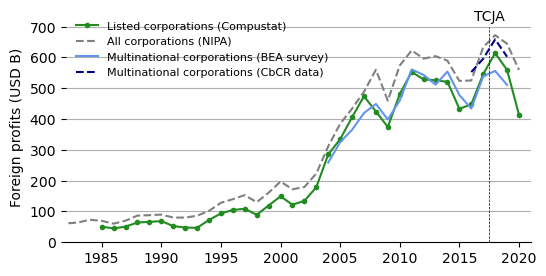

In [8]:
# Share of foreign profits
plt.figure(figsize=(6,3))

plt.plot(comp.index, 100*comp.share_fo,".-", color="forestgreen",label="Listed corporations (Compustat)")
plt.plot(nat_acc.index,100*nat_acc.share_fo,"--", color="gray",label="All corporations (NIPA)")
plt.plot(df_usa.index,100*df_usa[16], color="cornflowerblue",label="Multinational corporations (BEA survey)")
#plt.plot([2019, 2020, 2021],df_usa2, ".", color="cornflowerblue",label="Multinational corporations (BEA survey)")
plt.plot(cbcr_sf.index,100*cbcr_sf.share_fo, "--",color="navy",label="Multinational corporations (CbCR data)")
plt.xlim(1982, 2021.5)
plt.legend(frameon=False, fontsize=8)
plt.gca().grid(axis='y')
sns.despine(bottom=False,left=True)
plt.ylim(0,100*0.7)
plt.ylabel("Share of foreign profits (%)")

# Vertical bar at 2017.5
plt.plot([2017.5, 2017.5], [0, 100*0.64], color="black", linestyle="--", linewidth=0.5)
plt.annotate("TCJA", (2017.5, 100*0.65), ha='center', va='bottom')

plt.savefig("results/figures/foreign_profits_share.pdf",bbox_inches="tight")


# Share of foreign profits
plt.figure(figsize=(6,3))
plt.plot(comp.index,comp.pifo_all/1E3,".-", color="forestgreen",label="Listed corporations (Compustat)")
plt.plot(nat_acc.index,nat_acc.Rest,"--", color="gray",label="All corporations (NIPA)")
plt.plot(bea_sf.index,bea_sf.Rest/1E9, color="cornflowerblue",label="Multinational corporations (BEA survey)")
plt.plot(cbcr_sf.index,cbcr_sf.Rest/1E9, "--",color="navy",label="Multinational corporations (CbCR data)")
plt.xlim(1982, 2021)
plt.legend(frameon=False, fontsize=8)
plt.gca().grid(axis='y')
sns.despine(bottom=False,left=True)
plt.ylim(0,750)
# Vertical bar at 2017.5
plt.plot([2017.5, 2017.5], [0, 700], color="black", linestyle="--", linewidth=0.5)
plt.annotate("TCJA", (2017.5, 710), ha='center', va='bottom')


plt.ylabel("Foreign profits (USD B)")
plt.savefig("results/figures/foreign_profits_total.pdf",bbox_inches="tight")

## Figure 2: Misalignment of profits and activity

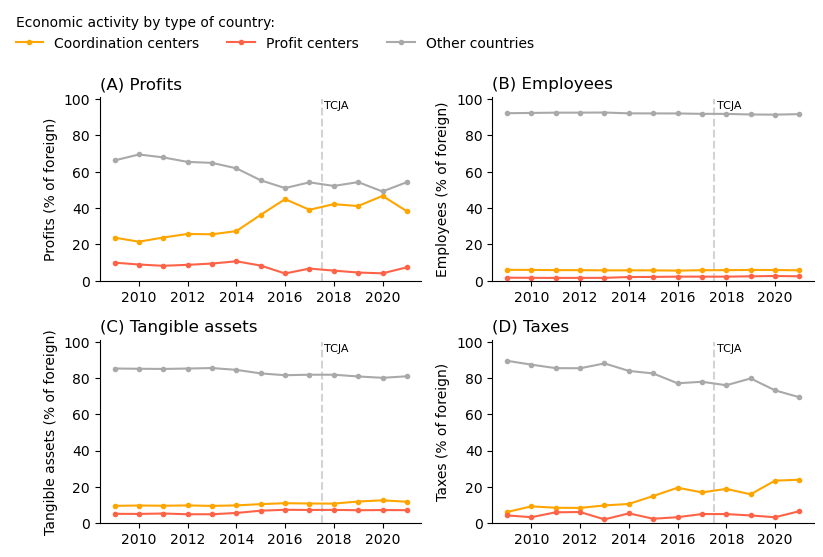

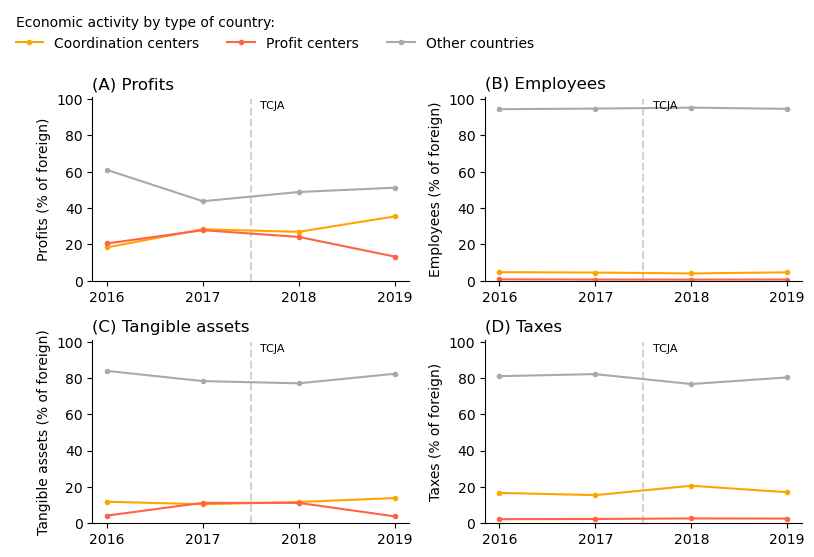

In [9]:
var_study = ["pi", "emp", "t_at", "txt"]
for source in ["BEA_return", "CBCR"]:
    df["country_type"] = df["iso"].map(lambda x: "Profit" if x in island_states else ("Coordination" if x in dev_haven else "Other"))
    df_foreign = df.loc[(df["type"]=="all_groups") & (df["iso"] == "Rest") & (df["source"]==source), ["year"] + var_study]
    df_foreign.columns = ["year"] + [f"for_{var}" for var in var_study]
    
    
    df_x = df.loc[(df["type"]=="all_groups") & (df["iso"].isin(island_states + dev_haven)) & (df["source"]==source)]
    df_x = df_x.groupby(["country_type", "year"]).sum().reset_index()
    df_x = pd.merge(df_x[["country_type", "year"] + var_study], df_foreign, how="outer")
    for var in var_study:
        df_x[f"for_share_{var}"] = df_x[var] / df_x[f"for_{var}"]
    df_x = df_x.loc[df_x["year"] > 2008]
    
    plt.figure(figsize=(8, 5))
    for i, var in enumerate(var_study):
        if var == "pi":
            var_label = "profits"
        elif var == "emp":
            var_label = "employees"
        elif var == "t_at":
            var_label = "tangible assets"
        elif var == "at":
            var_label = "total assets"
        elif var == "txt":
            var_label = "taxes"
            
        sum_values = None
        ax = plt.subplot(2,2,i+1)
        
        plt.ylabel(f"{var_label.capitalize()} (% of foreign)")
        for t, data in df_x.groupby("country_type"):
            ax.plot(data["year"], 100*data[f"for_share_{var}"], marker = ".", label=f"{t} centers", color={"Profit": "tomato", "Coordination": "orange"}[t])
            if sum_values is None:
                sum_values = 100 - 100*data[f"for_share_{var}"].values
            else:
                sum_values -=  100*data[f"for_share_{var}"].values
        ax.plot(data["year"], sum_values, marker=".", label=f"Other countries", color="darkgray")
        ax.plot([2017.5, 2017.5], [0, 100], "--", color="lightgray", zorder=0)
        ax.annotate("TCJA", (2017.6, 99), ha="left", va="top", fontsize=8)
        plt.title(f"({'ABCD'[i]}) {var_label.capitalize()}", loc="left")
        
        sns.despine()
        plt.ylim(0,101)
        if len(data["year"]) < 6:
            plt.xticks(data["year"], data["year"])
    plt.tight_layout()
    leg = plt.legend(bbox_to_anchor=(-1.5, 2.8), loc=2, borderaxespad=0.,ncol=3,frameon=False, title="Economic activity by type of country:")
    leg._legend_box.align = "left"

    plt.savefig(f"results/figures/fig2_share_haven_{source}.pdf",bbox_inches="tight")

    plt.show()


## Figure 3: Profits booked in tax havens --> See Excel file (data/GJZ2021Data.xlsx)

## Figure 4: Extreme profitability in tax havens

/Users/garci061/miniforge3/envs/test3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


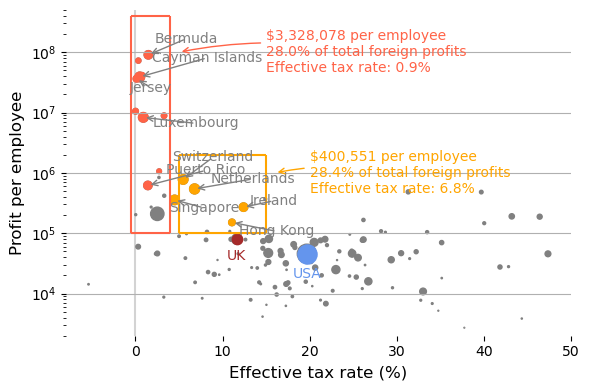

/Users/garci061/miniforge3/envs/test3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


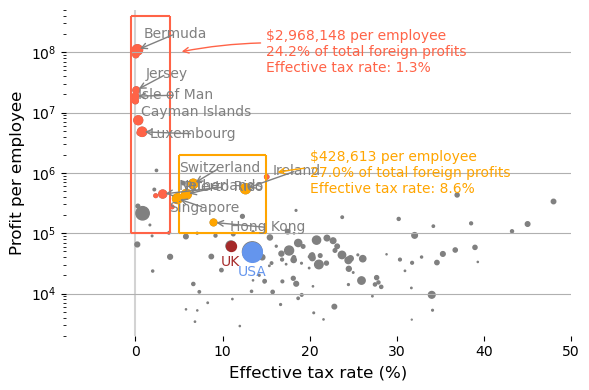

/Users/garci061/miniforge3/envs/test3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


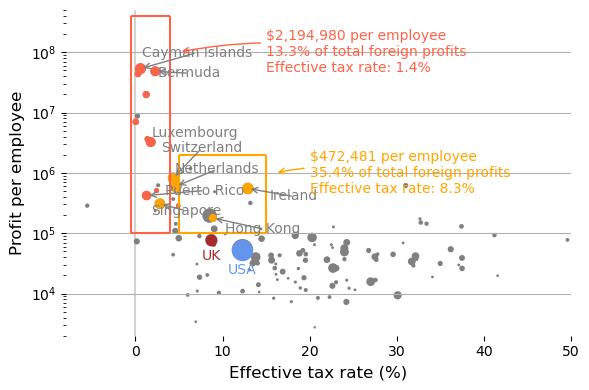

In [21]:
for source in ["CBCR"]:
    for year in [2017, 2018, 2019]:
        data_x = plot_pi_emp_detail(df.loc[df["year"]==year], source, iso3_to_name, dev_haven, island_states)
        plt.savefig(f"results/figures/{source}_etr_profit_{t}_both.pdf",bbox_inches="tight")
        plt.show()

## Figure 5: Changes in sensitiyivy of profits to tax rates

In [37]:


#Add region
oi = pd.read_csv("data_raw/gdps.csv",sep="\t")
oi = oi.rename(columns={"iso3": "iso"})
oi.head(10)

stat_rate = pd.read_excel("data_raw/1980-2021-Corporate-Tax-Rates-Around-the-World.xlsx", usecols=["iso_3","year","rate"])
stat_rate.columns = ["iso","year","statrate"]
stat_rate["statrate"] /= 100
stat_rate = stat_rate.dropna()
stat_rate.head()


df_b = pd.merge(df, oi, how="left", on=["iso","year"])
df_b = df_b.loc[df_b["source"]=="BEA_return"]
df_b = df_b.loc[df_b["type"]=="all_groups"]
df_b = df_b.loc[df_b["iso"] != "Rest"]
df_b = df_b.loc[(df_b["etr"]>=0) & (df_b["etr"]<0.5), ["iso","year","pi","etr","t_at","wages","revenue_unrelated","GDP_int","POP_int"]].dropna()
df_b.loc[df_b["iso"]=="CAN"]
df_b["reform"] = (df_b["year"]>=2018).astype(int)
df_b = df_b.loc[df_b["iso"].isin(cs)]
df_b["haven"] = df_b["iso"].isin(tax_havens)

df_b_full = pd.merge(df_b, stat_rate)
df_b_full.head()

,iso,year,pi,etr,t_at,wages,revenue_unrelated,GDP_int,POP_int,reform,haven,statrate
0,ARG,2011,5.440000e+09,0.422978,1.744000e+10,4.504000e+09,3.737400e+10,5.301633e+11,41261490.0,0,False,0.3500
1,AUS,2011,2.042500e+10,0.221689,6.993700e+10,2.506200e+10,1.434960e+11,1.396650e+12,22340024.0,0,False,0.3000
2,BEL,2011,7.038000e+09,0.220091,1.621700e+10,1.223200e+10,9.031700e+10,5.226455e+11,11038264.0,0,False,0.3399
3,BMU,2011,6.984000e+09,0.036512,7.708000e+09,2.930000e+08,9.744000e+09,5.550771e+09,64564.0,0,True,0.0000
4,BRA,2011,1.474500e+10,0.282740,4.580000e+10,2.172200e+10,1.610720e+11,2.616201e+12,197514534.0,0,False,0.3400


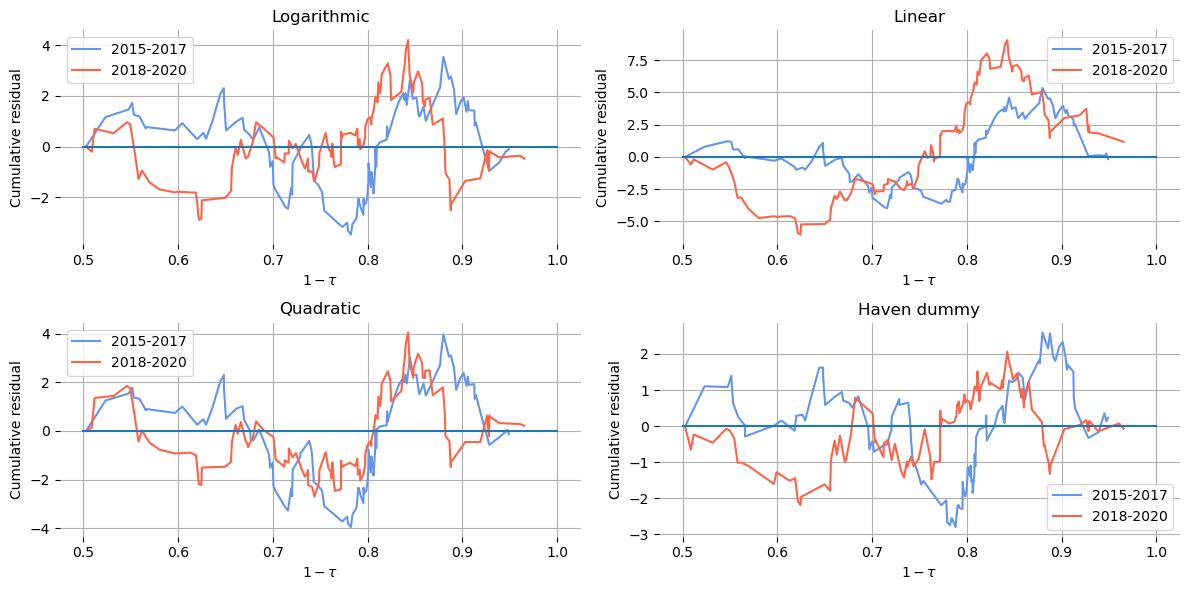

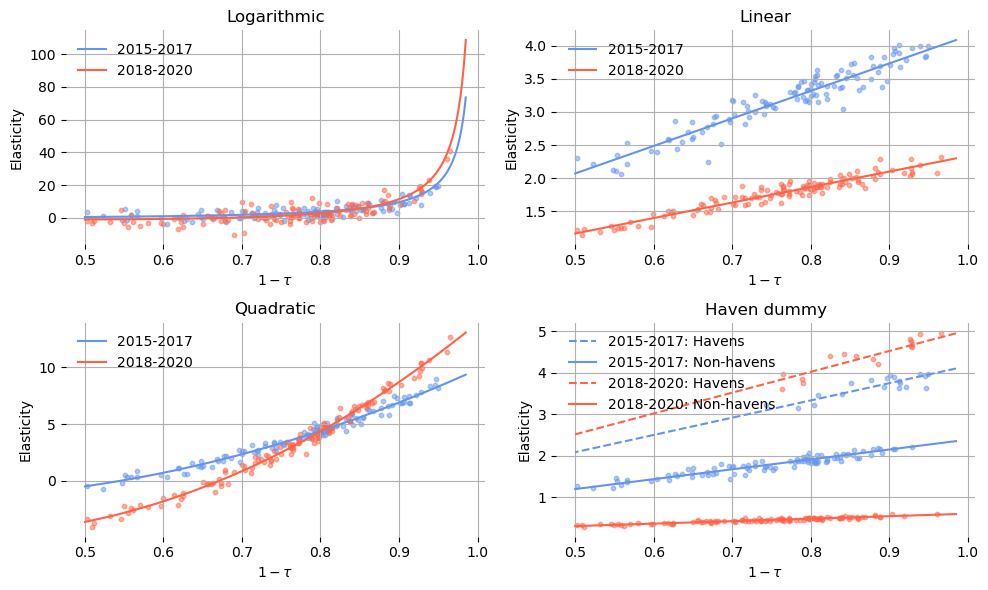

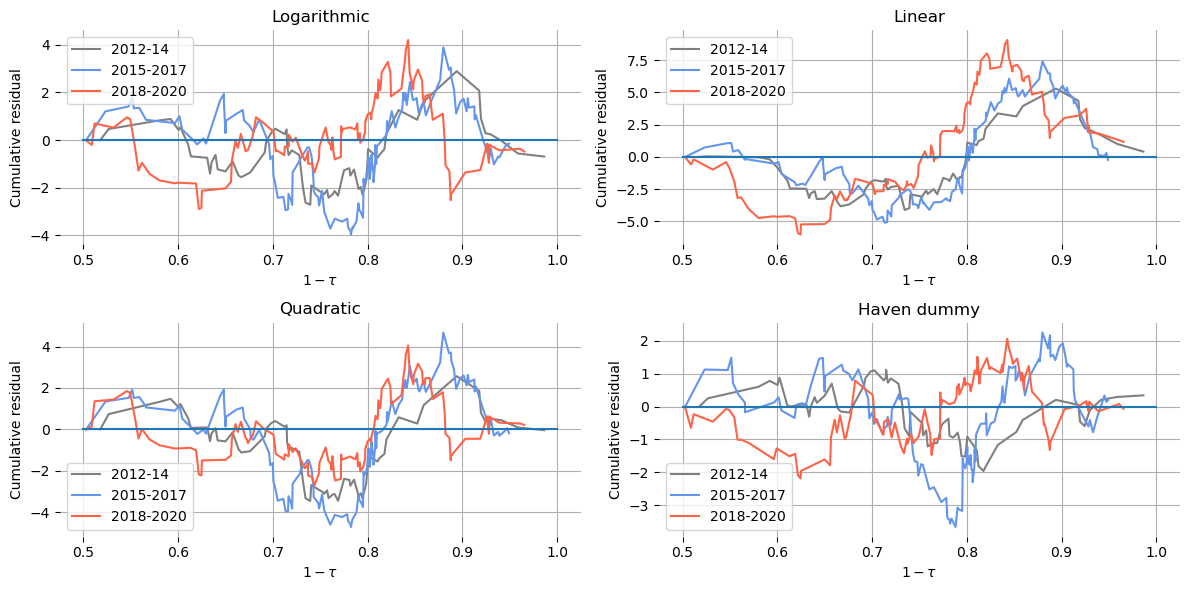

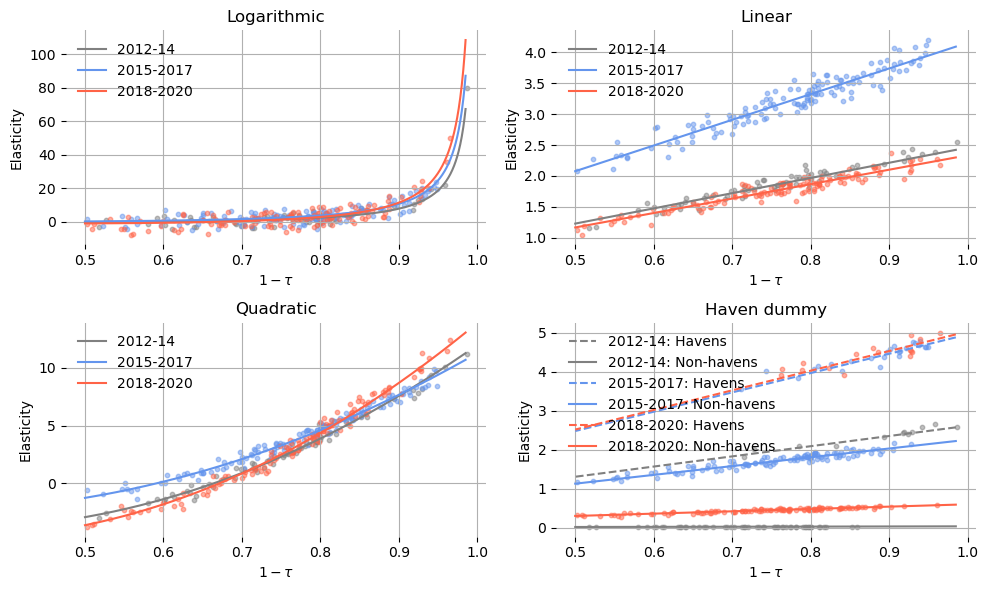

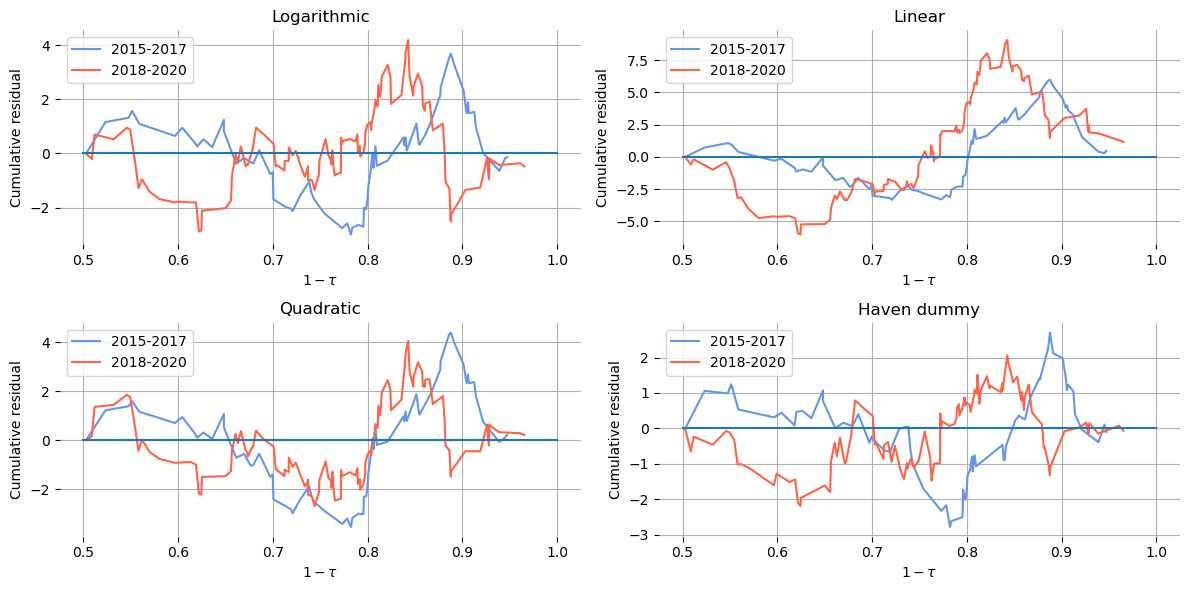

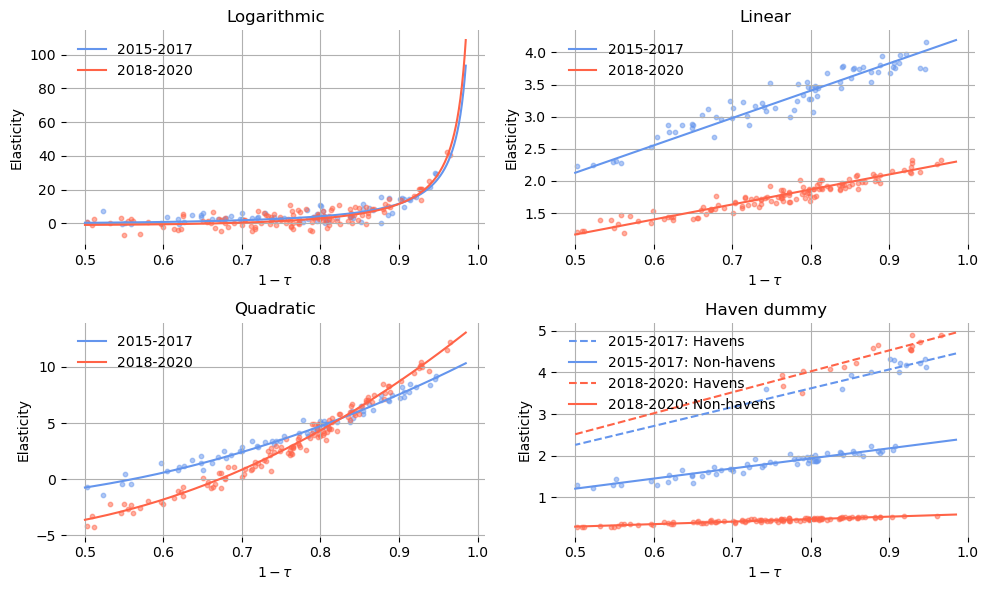

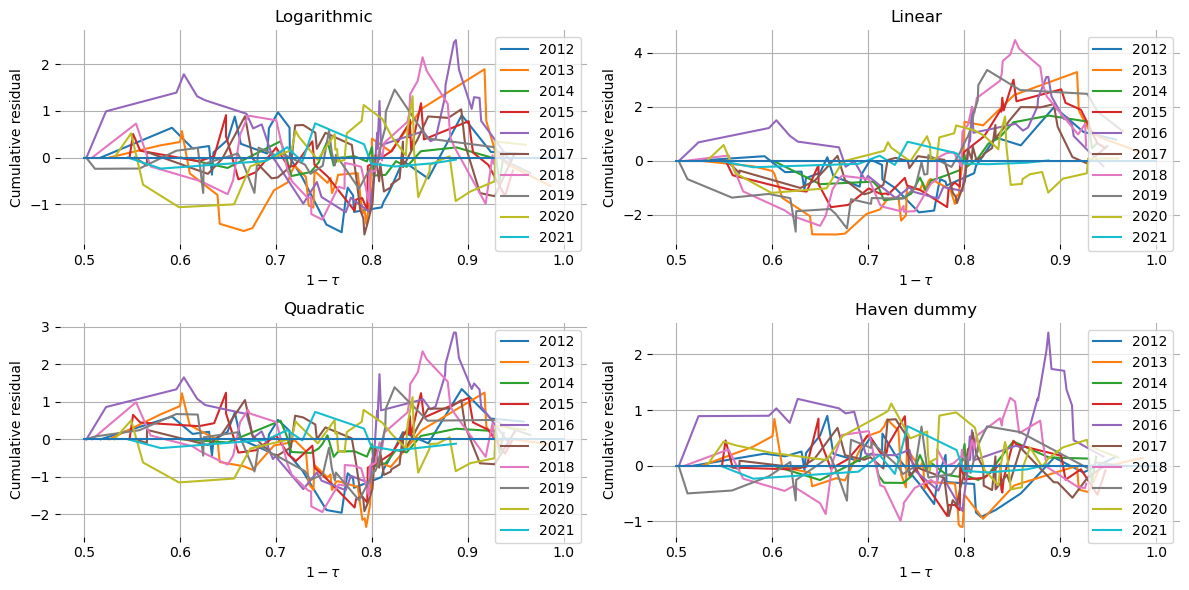

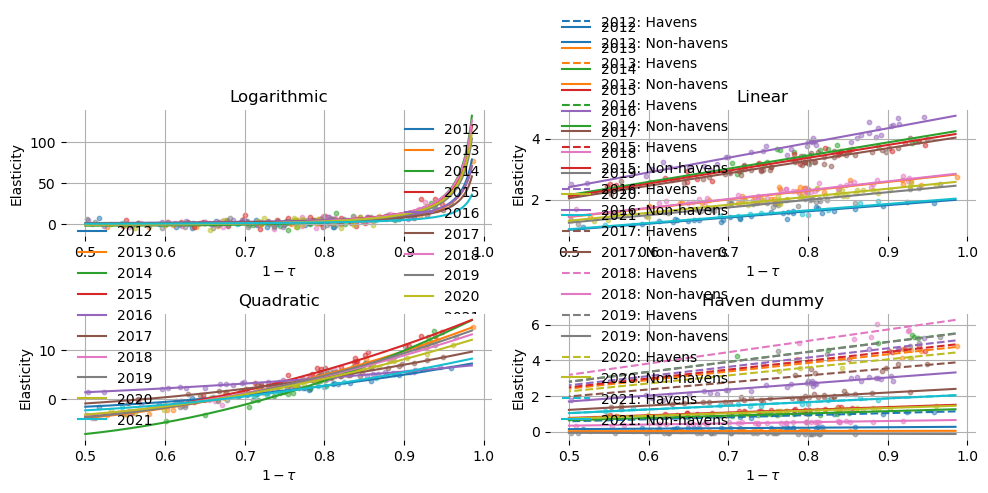

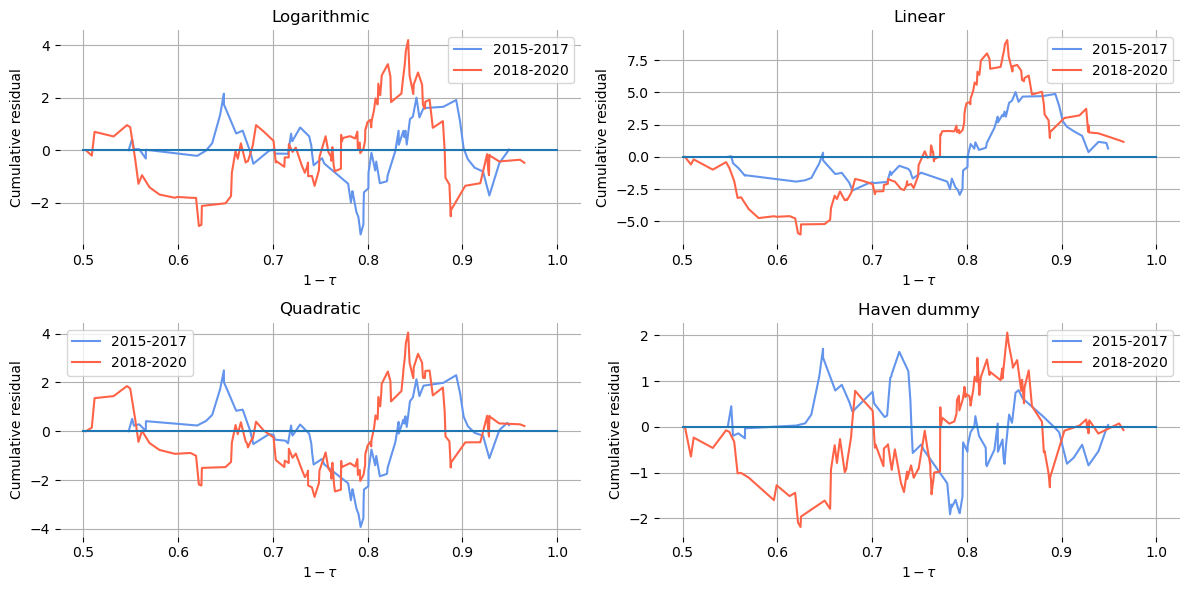

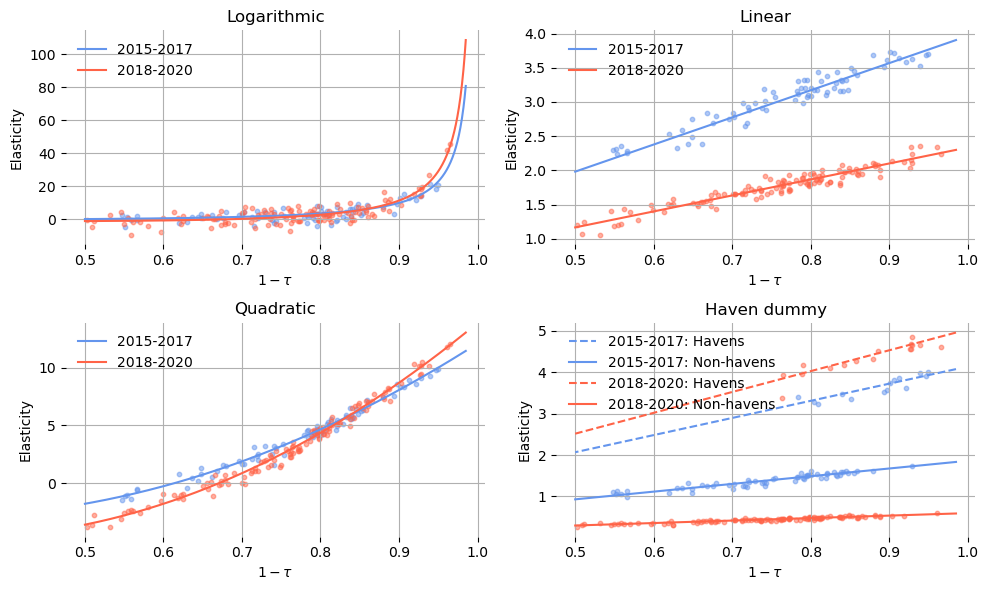

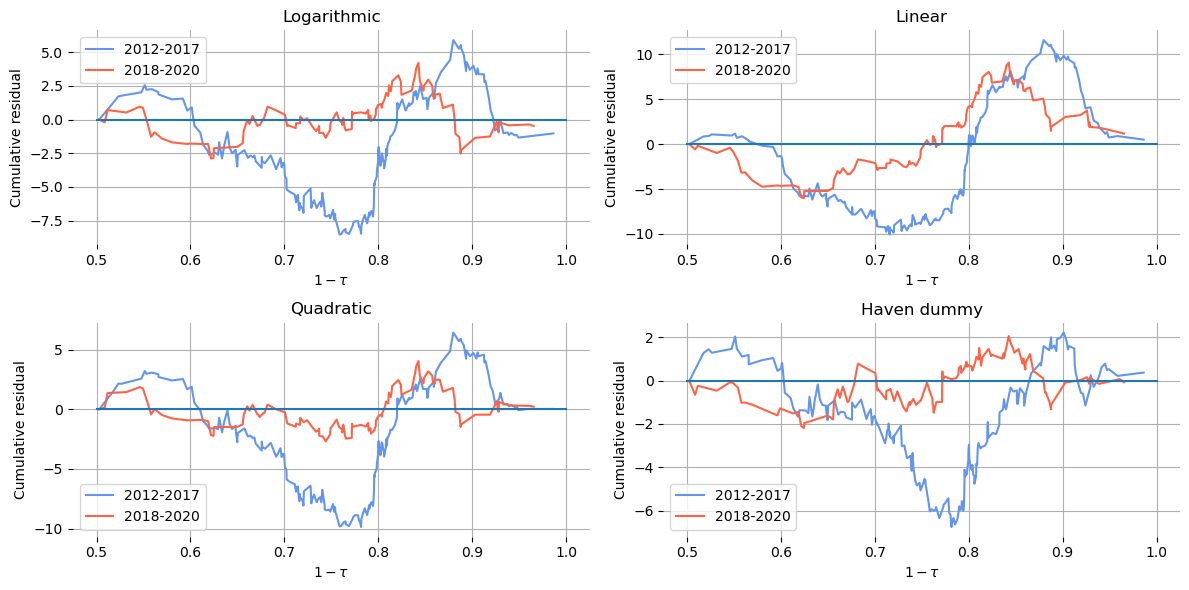

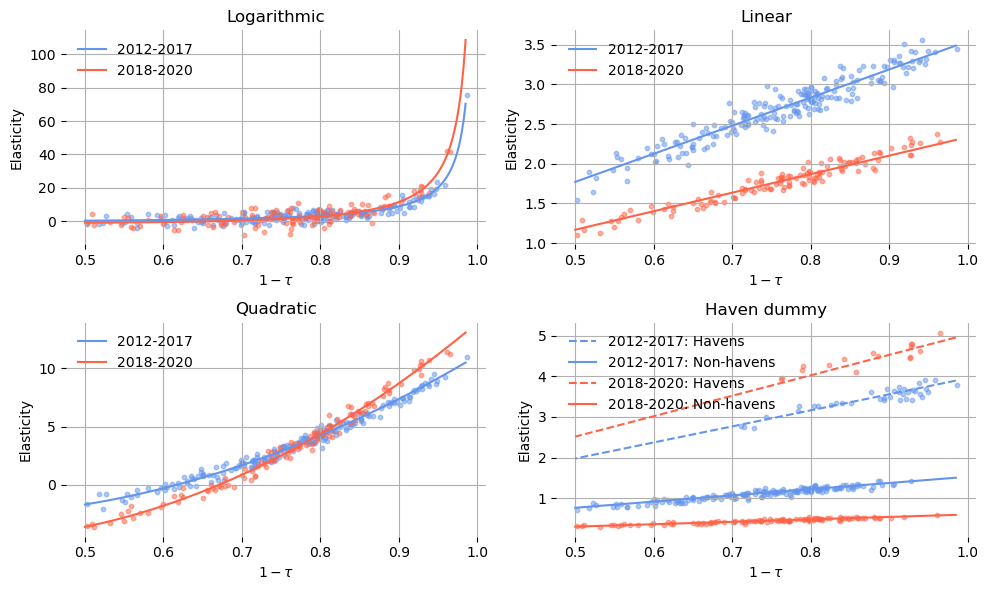

In [34]:
#General plot
plots(df_b_full.loc[df_b_full["year"]>2014], prefix="", add="+ C(year)", tax_havens=tax_havens)
#Robusteness 1
plots(df_b_full.loc[df_b_full["year"]>2011], prefix="rob1_", add="+ C(year)", tax_havens=tax_havens)

#Robusteness 2
plots(df_b_full.loc[(df_b_full["year"]>2014)&(df_b_full["year"]!=2017)], prefix="rob2_", add="+ C(year)", tax_havens=tax_havens)

#Robusteness 3 (by year)
plots(df_b_full.loc[df_b_full["year"]>2011], prefix="rob3_by_year_", by_year=True, add="+ C(year)", tax_havens=tax_havens)

#Robusteness 2
plots(df_b_full.loc[(df_b_full["year"]>2014)&(df_b_full["year"]!=2016)], prefix="rob2b_", add="+ C(year)", tax_havens=tax_havens)

#Smoothing out
plots(df_b_full.loc[df_b_full["year"]>2011], prefix="rob5_", reform=lambda x: 0 if x<=2017 else 1, get_label=lambda x: ['2012-2017','2018-2020'][x], add="+ C(year)", tax_havens=tax_havens)



# Appendix
## Table A1 --> below
## Figures A2 and A3 (robustness tests) --> see notebook 3b
## Figure A4 (comparing sources aggregated) --> see Excel file (data/GJZ2021Data.xlsx)
## Figure A5 and A11 (comparing sources) --> below
## Figure A6 (individual companies, compustat) --> see notebook 1a (bottom-ish)
## Figure A7 (by sector , compustat) --> see notebook 1a (bottom-ish)
## Figure A8 (individual firms, profits) --> see methodology note above and Table A4, proprietary data
## Figure A9 and A10 (share of profits in tax havens) --> created above together with Figure 2
## Figure A12 (evolution of net interest paid) --> below
## Figure A13 (evolution of capital gains) --> see notebook 1a (bottom)
## Figure A14 (evolutions of profits/wages ratio) --> below
## Figure A15 (sensitivity of profits to tax rates) --> created above together with Figure 5
## Table A2 ---> see main text, data of cells in notebook 1a
## Table A3 --> see notebook 3b
## Table A5 --> 

In [16]:
## Table A1

comp_profits = pd.read_csv("./data/compustat_profits.csv")
comp_profits = comp_profits.rename(columns={"fyear":"year"}).set_index("year")[["pifo","Share of profits made by companies with info on foreign profits"]]

profits = df.loc[(df["type"]=="all_groups")&(df["iso"]=="Rest")].groupby(["year","source"])["pi"].sum().reset_index()
profits = pd.pivot_table(profits, index = "year", columns = "source", values = "pi")
profits = pd.concat([profits,comp_profits], axis=1).sort_index()
profits = profits.loc[1990:2020] / 1E9
profits["Share of profits made by companies with info on foreign profits"] *= 1E11
profits = profits.round(1)
profits.columns = ["DI equity income","Profit-type return","Profit-type return + CG","CBCR","CFC","Compustat","Compustat (\% info)"]
profits = profits.reset_index().replace(0,np.nan)

latex_table =  profits.to_latex(index=False,column_format="p{1.5cm}"*profits.shape[1],float_format="%.1f",na_rep="")

with open("results/compustat_appendix.tex", "w+") as f:
    f.write(latex_table)


<>:12: SyntaxWarning: invalid escape sequence '\%'
<>:12: SyntaxWarning: invalid escape sequence '\%'
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_79428/1238379995.py:12: SyntaxWarning: invalid escape sequence '\%'
  profits.columns = ["DI equity income","Profit-type return","Profit-type return + CG","CBCR","CFC","Compustat","Compustat (\% info)"]


2014 CFC BEA_income SignificanceResult(statistic=0.7666666666666667, pvalue=3.23038409684608e-12)
2016 CFC BEA_income SignificanceResult(statistic=0.8195121951219512, pvalue=4.424599597599679e-14)
2014 CFC BEA_return SignificanceResult(statistic=0.7717948717948718, pvalue=2.317272815455349e-12)
2016 CFC BEA_return SignificanceResult(statistic=0.6780487804878048, pvalue=4.239151048613769e-10)


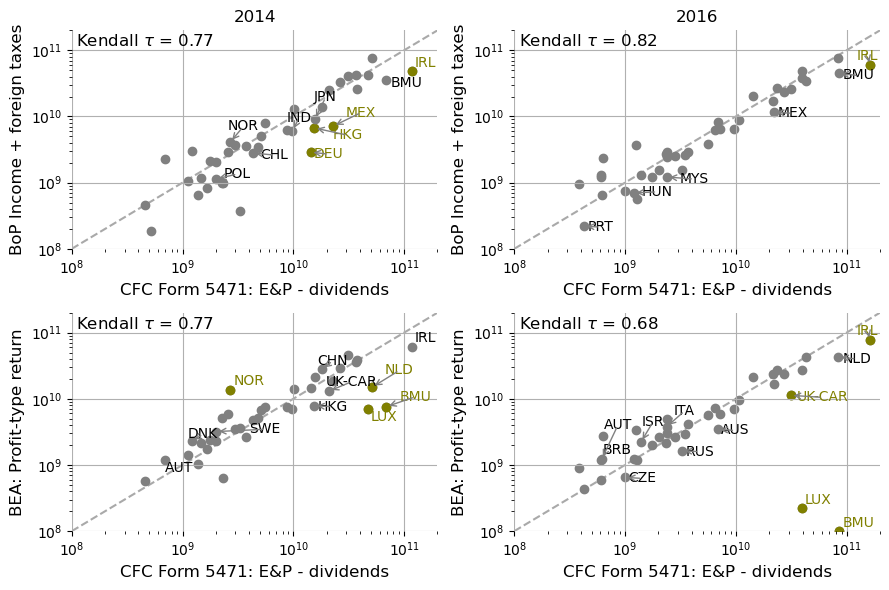

2017 CBCR BEA_income SignificanceResult(statistic=0.7541654809195802, pvalue=3.280491313211746e-17)
2018 CBCR BEA_income SignificanceResult(statistic=0.7381648158971361, pvalue=1.4644046152376534e-16)
2019 CBCR BEA_income SignificanceResult(statistic=0.7242399930491318, pvalue=5.925214001338135e-16)
2017 CBCR BEA_return SignificanceResult(statistic=0.7790765634132085, pvalue=2.853262231583539e-18)
2018 CBCR BEA_return SignificanceResult(statistic=0.7600117249577164, pvalue=1.8713195204805246e-17)
2019 CBCR BEA_return SignificanceResult(statistic=0.7911726173584007, pvalue=4.751466807551026e-19)


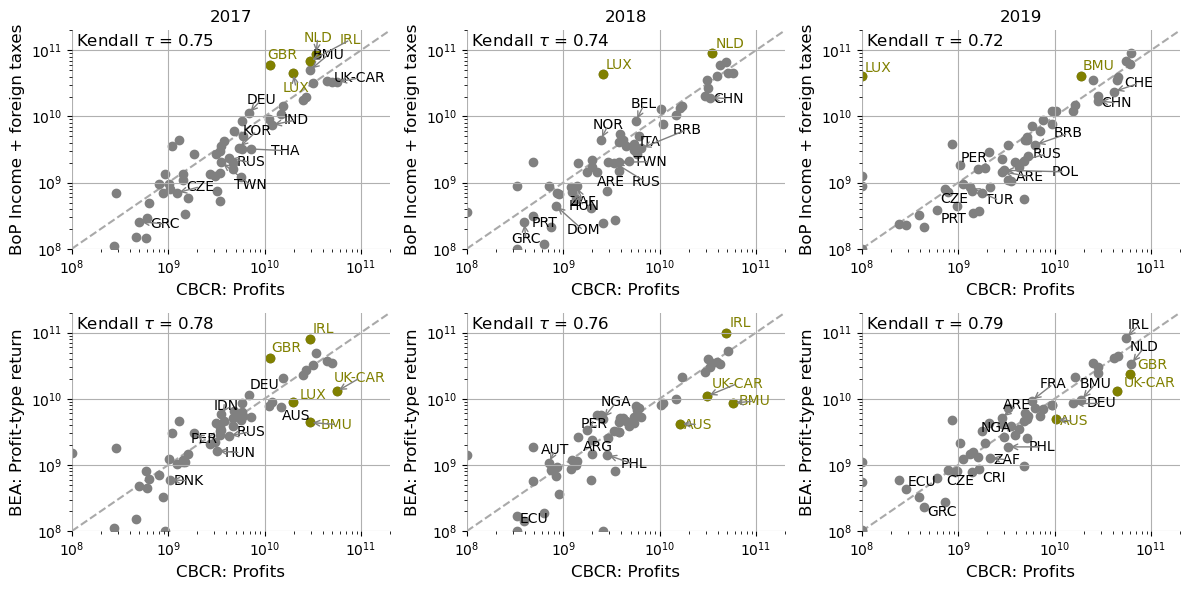

2015 BEA_return BEA_return_cg SignificanceResult(statistic=0.857143211979204, pvalue=2.518264754316781e-21)
2016 BEA_return BEA_return_cg SignificanceResult(statistic=0.949506609368178, pvalue=4.72258152103981e-27)
2017 BEA_return BEA_return_cg SignificanceResult(statistic=0.9661016949152543, pvalue=3.9806383810509206e-28)
2018 BEA_return BEA_return_cg SignificanceResult(statistic=0.9485495347564313, pvalue=4.015499990271837e-27)
2019 BEA_return BEA_return_cg SignificanceResult(statistic=0.9375661375661376, pvalue=5.109398445380878e-27)
2020 BEA_return BEA_return_cg SignificanceResult(statistic=0.9246684350132626, pvalue=3.2979840452940664e-26)


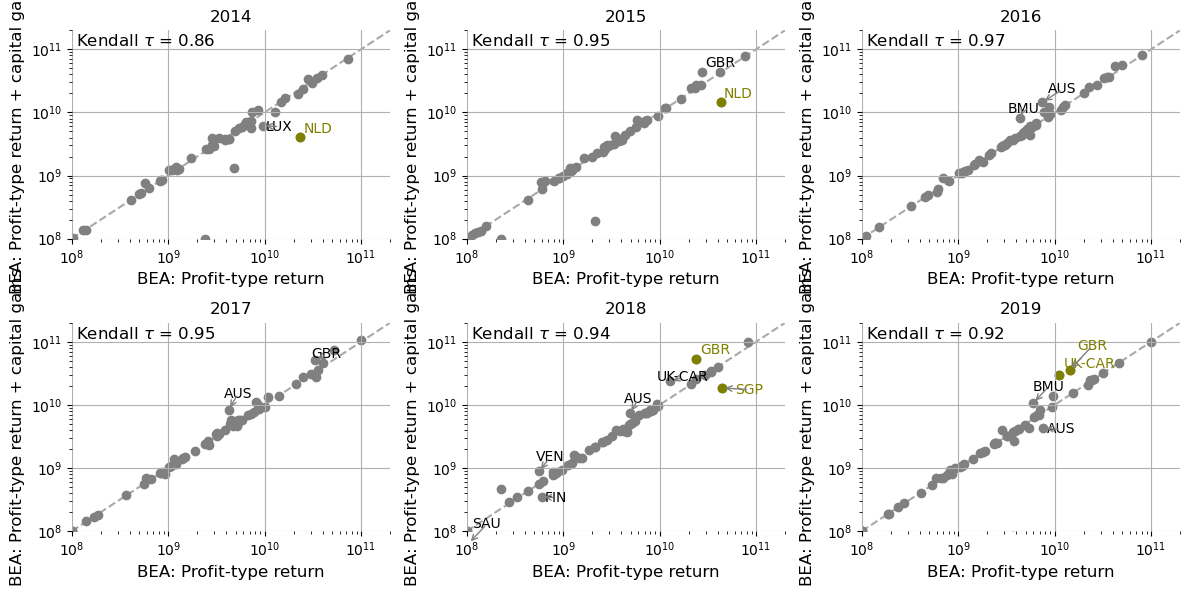

In [18]:
## Figure A5 and A11 (and one extra comparisoiin)

plt.figure(figsize=(9,6))
plt.subplot(2,2,1)
plot_compare(df,2014,"CFC","BEA_income")
plt.title("2014")
plt.subplot(2,2,2)
plot_compare(df,2016,"CFC","BEA_income")
plt.title("2016")
plt.subplot(2,2,3)
plot_compare(df,2014,"CFC","BEA_return")
plt.subplot(2,2,4)
plot_compare(df,2016,"CFC","BEA_return")
plt.tight_layout()
plt.savefig(f"results/figures/cfc_vs_bea.pdf",bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plot_compare(df,2017,"CBCR","BEA_income")
plt.title("2017")
plt.subplot(2,3,2)
plot_compare(df,2018,"CBCR","BEA_income",correct=True)
plt.title("2018")
plt.subplot(2,3,3)
plot_compare(df,2019,"CBCR","BEA_income",correct=True)
plt.title("2019")
plt.subplot(2,3,4)
plot_compare(df,2017,"CBCR","BEA_return")
plt.subplot(2,3,5)
plot_compare(df,2018,"CBCR","BEA_return",correct=True)
plt.subplot(2,3,6)
plot_compare(df,2019,"CBCR","BEA_return")
plt.tight_layout()
plt.savefig(f"results/figures/cbcr-corrected_vs_bea.pdf",bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plot_compare(df,2015,"BEA_return", "BEA_return_cg")
plt.title("2014")
plt.subplot(2,3,2)
plot_compare(df,2016,"BEA_return", "BEA_return_cg")
plt.title("2015")
plt.subplot(2,3,3)
plot_compare(df,2017,"BEA_return", "BEA_return_cg")
plt.title("2016")

plt.subplot(2,3,4)
plot_compare(df,2018,"BEA_return", "BEA_return_cg")
plt.title("2017")
plt.subplot(2,3,5)
plot_compare(df,2019,"BEA_return", "BEA_return_cg")
plt.title("2018")
plt.subplot(2,3,6)
plot_compare(df,2020,"BEA_return", "BEA_return_cg")
plt.title("2019")
plt.tight_layout()
plt.savefig(f"results/figures/capital_gains_vs_bea.pdf",bbox_inches="tight")
plt.show()

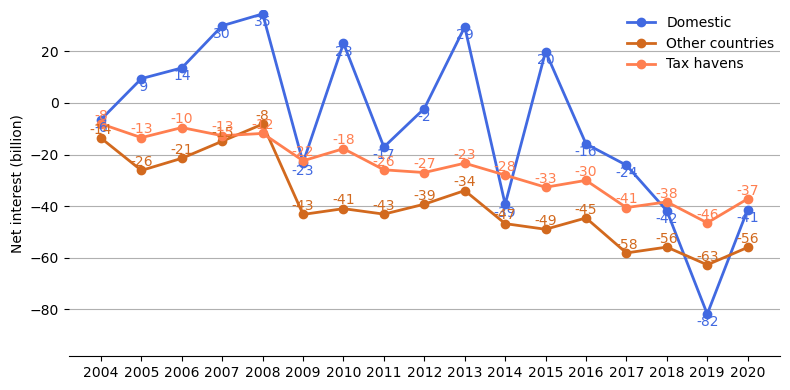

In [30]:
# Figure A12 (net interest)
df["interest_ratio"] = df["net_interest"]/df["pi"]
df["net_interest_bil"] = df["net_interest"]/1E9
source = "BEA_return"

plt.figure(figsize=(8,4))
# plt.subplot(221)
plot_evol_variable(df.loc[(df["year"]>2003)&(df["year"]<2021)],source,var="net_interest_bil",
                   ylabel="Net interest (billion)",letter="A",flag_normalize=False, tax_havens=tax_havens)
plt.savefig("results/figures/figA12_net_interest.pdf",bbox_inches="tight")

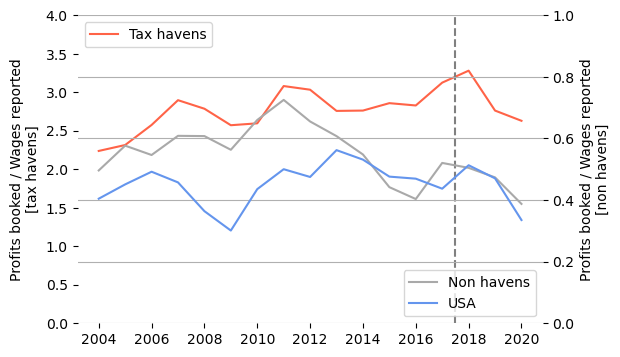

In [43]:
df_b = pd.merge(df.loc[df["year"]<2021], oi, how="left", on=["iso","year"])
df_b["pw"] = df_b["pi"]/df_b["wages"]
df_b = df_b.loc[df_b["source"]=="BEA_return"]
df_b = df_b.loc[df_b["iso"] != "Rest"]
df_b["reform"] = (df_b["year"]>=2018).astype(int)
df_b["haven"] = (df_b["iso"].isin(tax_havens)).astype(int)

    
def clas_count(c):
    if c in island_states + dev_haven:
        return "Tax havens"
    elif c == "USA":
        return "USA"
    else:
        return "Non havens"
    
def clas_count_col(c):
    if c in island_states + dev_haven:
        return "tomato"
    elif c == "USA":
        return "cornflowerblue"
    else:
        return "darkgray"
    
df_b["country"] = df_b["iso"].map(clas_count)
df_b["color"] = df_b["iso"].map(clas_count_col)

plt.figure(figsize=(6,4))
df_b2 = df_b.groupby(["country","year","color"]).sum().reset_index().set_index("country")
df_b2["pw"] = df_b2["pi"]/df_b2["wages"]

for c in ["Tax havens"]:
    plt.plot(df_b2.loc[c, "year"], df_b2.loc[c, "pw"], label=c, color=df_b2.loc[c, "color"].values[0])

plt.ylim(0,4)
plt.plot([2017.5, 2017.5],[0,4],"--",color="gray")
plt.ylabel("Profits booked / Wages reported\n[tax havens]")
plt.legend(frameon=True, fontsize=10, loc=2)

plt.gca().twinx()

for c in ["Non havens", "USA"]:
    plt.plot(df_b2.loc[c, "year"], df_b2.loc[c, "pw"], label=c, color=df_b2.loc[c, "color"].values[0])

plt.ylim(0,1)
plt.ylabel("Profits booked / Wages reported\n[non havens]")


sns.despine(bottom=True, left=True)
plt.grid(axis="y")
plt.legend(frameon=True, fontsize=10, loc=4)
plt.savefig(f"results/figures/profit_wage.pdf",bbox_inches="tight")

## Other useful figures

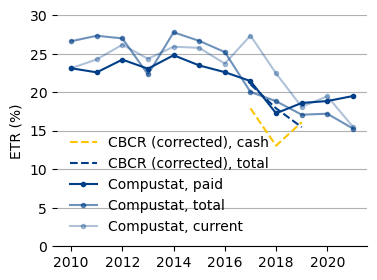

In [ ]:
comp = pd.read_excel("/Users/garci061/Dropbox/projects/Gabriel_Javier_Petr/RawData/compustat_etrs.xlsx")
comp = comp.loc[comp["fyear"]>2009]
cbcr_etr = df.loc[df["iso"].isin(["Rest","USA"]) & (df["source"]=="CBCR") & (df["type"] == "positive_groups"),["iso","type","year","txc","txt","pi"]]
cbcr_etr = cbcr_etr.groupby("year").sum()
cbcr_etr["etr_cash"] = cbcr_etr["txc"]/cbcr_etr["pi"]
cbcr_etr["etr_total"] = cbcr_etr["txt"]/cbcr_etr["pi"]

plt.figure(figsize=(4,3))
plt.plot(cbcr_etr.index,100*cbcr_etr["etr_cash"],"--", color="#FDC500",label="CBCR (corrected), cash")
plt.plot(cbcr_etr.index,100*cbcr_etr["etr_total"],"--", color="#003F88",label="CBCR (corrected), total")
plt.plot(comp["fyear"], comp["etr (paid)"], ".-",color="#003F88",label="Compustat, paid")
plt.plot(comp["fyear"], comp["etr (total)"], ".-",color="#003F8890",label="Compustat, total")
plt.plot(comp["fyear"], comp["etr (current)"], ".-",color="#003F8850",label="Compustat, current")


plt.legend(frameon=False)
plt.gca().grid(axis='y')
sns.despine(bottom=False,left=True)
plt.ylim(0,30)
plt.ylabel("ETR (%)")


-----